In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
Np = 1e5

In [145]:
mu = 1.85e-5 
p = 1.013e5   

tau = 2 * mu / p

def simulate_processes(Tf, T0, tau, m, Np=int(1e4)):
    k = 1.380649 * 1e-23
    m = 4.65e-26         # particle mass (e.g., N2 molecule) in kg

    #time_final = 5 / tau
    time_final = 10

    N = 10000
    dt = time_final / N
    
    # Np particles, N timesteps, 3 velocity components
    main_process = np.zeros((Np, N, 3))
    parallel_process = np.zeros((Np, N, 3))

    sigma = np.sqrt(k * T0 / m)
    # Initial Condition
    main_process[:, 0, :] = np.random.normal(0, sigma, size=(Np, 3))
    parallel_process[:, 0, :] = main_process[:, 0, :].copy()  # perfect correlation

    
    for n in range(N-1):
        xi = np.random.normal(0, 1, size=(Np, 3))  # same noise for main and parallel
        main_process[:, n+1, :] = main_process[:, n, :] * np.exp(-dt/tau) + np.sqrt((k*Tf/m)*(1 - np.exp(-2*dt/tau))) * xi
        parallel_process[:, n+1, :] = parallel_process[:, n, :] * np.exp(-dt/tau) + np.sqrt((k*T0/m)*(1 - np.exp(-2*dt/tau))) * xi
        
    return main_process, parallel_process

def calculate_T(main_process, parallel_process, m, T0):

    k = 1.380649e-23
    # sum of squares over 3D components
    main_sq = np.sum(main_process**2, axis=2)       # shape (Np, N)
    parallel_sq = np.sum(parallel_process**2, axis=2)
    
    # average over particles
    avg_diff = np.mean(main_sq - parallel_sq, axis=0)  # shape (N,)
    
    # variance-reduced temperature
    T = T0 + (m / (3 * k)) * avg_diff
    return T  
def calculate_T_old(main_process, m, T0):

    k = 1.380649e-23
    # sum of squares over 3D components
    main_sq = np.sum(main_process**2, axis=2)       # shape (Np, N)
    
    # average over particles
    avg_diff = np.mean(main_sq, axis=0)  # shape (N,)
    
    # variance-reduced temperature
    T = (m / (3 * k)) * avg_diff
    return T  
    

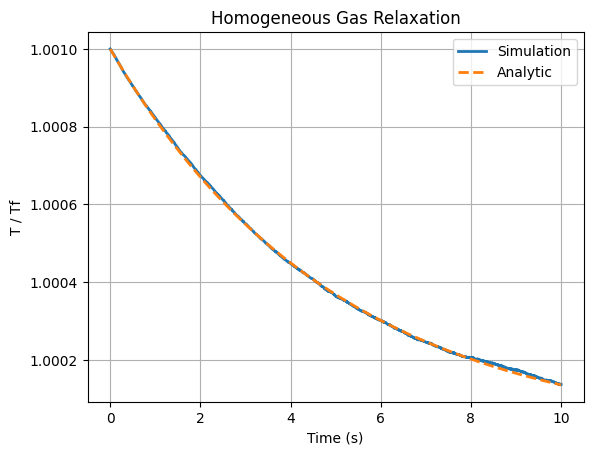

In [149]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.001 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T(main_process, parallel_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

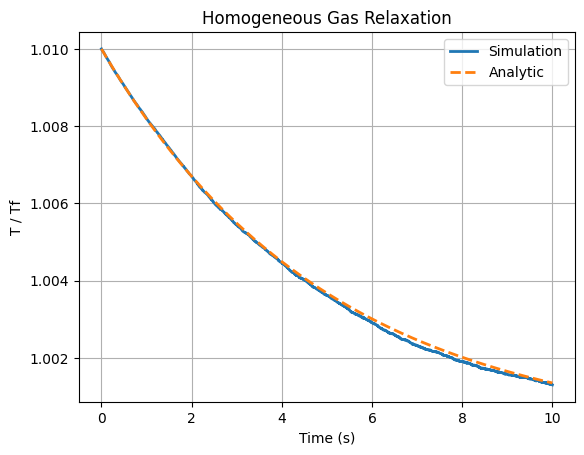

In [150]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.01 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T(main_process, parallel_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

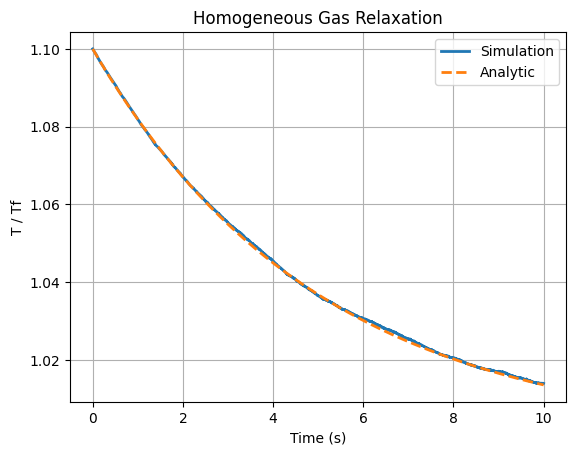

In [151]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.1 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T(main_process, parallel_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

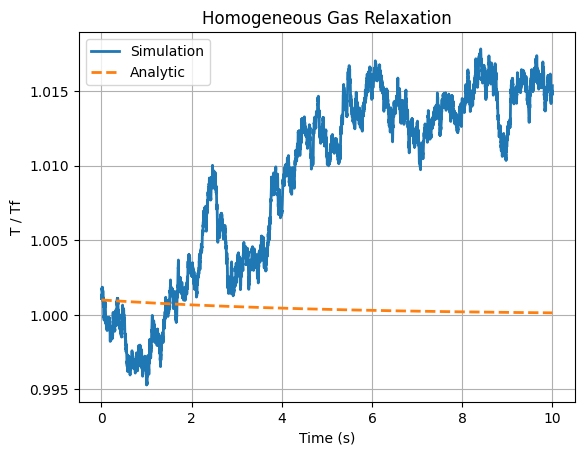

In [152]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.001 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T_old(main_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

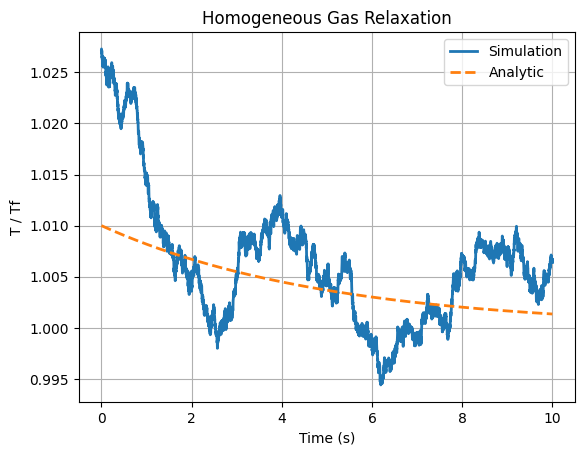

In [153]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.01 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T_old(main_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

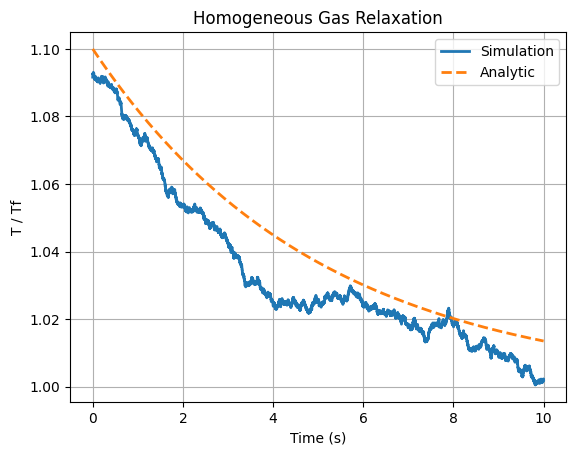

In [154]:
# Homogenous relaxation of gas
Tf = 300
T0 = 1.1 * Tf
m = 4.65e-26      # particle mass (kg)

main_process, parallel_process = simulate_processes(Tf, T0, 10, m)
temps = calculate_T_old(main_process, m, T0)

time_final = 10
N = 10000
time = np.linspace(0, time_final, N)

# Simulation (normalized)
T_sim = temps / Tf

# ---- Analytic solution ----
tau = 10   # <-- use the exact tau from simulate_processes
T_analytic = 1 + (T0/Tf - 1) * np.exp(-2 * time / tau)

# ---- Plot ----
plt.plot(time, T_sim, linewidth=2, label="Simulation")
plt.plot(time, T_analytic, '--', linewidth=2, label="Analytic")

plt.ticklabel_format(useOffset=False)
plt.xlabel('Time (s)')
plt.ylabel('T / Tf')
plt.title('Homogeneous Gas Relaxation')
plt.legend()
plt.grid(True)
plt.show()

In [155]:
a = [1,2,3]
b = a
b[0] = 10
print(a)

[10, 2, 3]
